In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# Feed-forward Neural Network Model

The neural network model can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

For any $l=1:L$, $\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is the non-linear activation function applied component-wise.

For any $l=1:L$

$$
\begin{align*}
    &\boldsymbol{z}^{[l+1]} = W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\\
    \implies &\boldsymbol{a}^{[l+1]} = \boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})
\end{align*}
$$

The total loss function $\mathcal{L}$ is function of the actual class labels $y_{i}$ and the network output for all the datapoints $\boldsymbol{a}^{[L]}_i$.

To help the network learn, the weights are updated using common gradient-based optimizers such as stochastic gradient descent and Adam. For this, the gradient of the loss function w.r.t. the parameters must be accurately calculated using the backpropogation chain rule.

The gradient of the loss function w.r.t. $\boldsymbol{b}^{[l]}$ can be calculated as follows:
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

Here,

$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = \text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

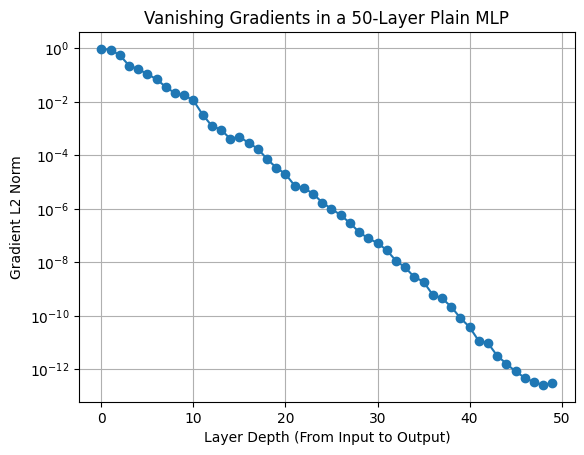

In [12]:
class MLP(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=1, num_layers=50):
        super(MLP, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Fully Connected / Dense
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Fully Connected
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Fully Connected Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # Layer 1 to L-1: Dense -> Tanh
        # Tanh is used here to easily demonstrate the vanishing gradient effect
        x = x.view(x.size(0), -1)
        for i in range(len(self.layers) - 1):
            x = F.tanh(self.layers[i](x))
            
        # Layer L: Dense Output
        x = self.layers[-1](x)
        
        return x

# Setup the experiment
torch.manual_seed(42)
model = MLP(in_features=10, hidden_features=10, out_features=1, num_layers=50)

# Dummy data and loss
x = torch.randn(1, 10)
target = torch.tensor([[1.0]])
criterion = nn.MSELoss()

# Forward pass
output = model(x)
loss = criterion(output, target)

# Backward pass
loss.backward()

# Extract gradient norms for each layer
grad_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    grad_norms.append(norm)

# Reverse the list so it plots from a[1] (first hidden layer) to a[L] (output layer)
grad_norms.reverse()

# Plotting the results
plt.plot(grad_norms, marker='o')
plt.title("Vanishing Gradients in a 50-Layer Plain MLP")
plt.xlabel("Layer Depth (From Input to Output)")
plt.ylabel("Gradient L2 Norm")
plt.yscale("log")
plt.grid(True)
plt.show()

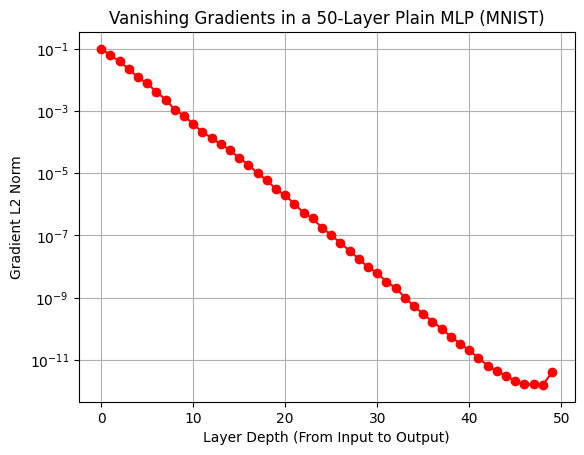

In [13]:
# 1. Load a single batch of MNIST data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Get one batch of images and labels
images, labels = next(iter(trainloader))

# 2. Setup the experiment
torch.manual_seed(42)
model = MLP(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
criterion = nn.CrossEntropyLoss()

# 3. Forward pass
output = model(images)
loss = criterion(output, labels)

# 4. Backward pass
loss.backward()

# 5. Extract and plot gradient norms
grad_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    grad_norms.append(norm)

grad_norms.reverse() # Reverse to plot from input layer to output layer

plt.plot(grad_norms, marker='o', color='red')
plt.title("Vanishing Gradients in a 50-Layer Plain MLP (MNIST)")
plt.xlabel("Layer Depth (From Input to Output)")
plt.ylabel("Gradient L2 Norm")
plt.yscale("log")
plt.grid(True)
plt.show()